# Pandas Data-Science Practice — Online Retail
**Your mission:** take a deliberately messy sales export and turn it into a clean dataset, a set of analyses, and a small dashboard.

Work top to bottom. Each phase feeds the next. Don't peek at the solutions notebook until you've made a real attempt — struggling with it *is* the learning.

Dataset: `messy_retail.csv` (keep it in the same folder as this notebook).

**Known landmines** (so you know what you're hunting): missing customer IDs, missing descriptions, cancelled invoices (`InvoiceNo` starting with `C`) with negative quantities, a few stray negative quantities that are plain errors, zero and absurd unit prices, quantity outliers (legit bulk vs. typos), inconsistent text casing/whitespace, three different date formats jumbled together, exact duplicate rows, and near-duplicate rows (same invoice+product, different quantity).

## Setup

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("messy_retail.csv", dtype={"InvoiceNo": str, "StockCode": str, "CustomerID": str})
df.shape

(5180, 8)

## Phase 1 — Cleaning

### Audit cell (already written for you)
Run this first. Read every line of output and write yourself a plain-English list of what's wrong **before** you fix anything. This habit is the whole game.

In [56]:
def audit(frame):
    print("SHAPE:", frame.shape)
    print("\nDTYPES:")
    print(frame.dtypes)
    print("\nNULLS per column:")
    print(frame.isna().sum())
    print("\nDUPLICATE rows (exact):", frame.duplicated().sum())
    print("\nNUMERIC summary:")
    print(frame.describe())
    print("\nQuantity range:", frame["Quantity"].min(), "to", frame["Quantity"].max())
    print("UnitPrice range:", frame["UnitPrice"].min(), "to", frame["UnitPrice"].max())
    print("\nSample of InvoiceDate values (note the mixed formats):")
    print(frame["InvoiceDate"].head(9).tolist())

audit(df)

SHAPE: (5180, 8)

DTYPES:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object

NULLS per column:
InvoiceNo        0
StockCode        0
Description     44
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     937
Country          0
dtype: int64

DUPLICATE rows (exact): 121

NUMERIC summary:
           Quantity     UnitPrice
count   5180.000000   5180.000000
mean     102.308301     28.687334
std     2642.346836    726.972603
min      -24.000000      0.000000
25%        6.000000      1.850000
50%       12.000000      2.750000
75%       18.000000      4.250000
max    80995.000000  38970.000000

Quantity range: -24 to 80995
UnitPrice range: 0.0 to 38970.0

Sample of InvoiceDate values (note the mixed formats):
['21/01/2011 13:25', '29/07/2011 06:54', '08/01/2011 19:05', '28/12/2011 09:41', '2011-06-04 12:36:00', '08-31-2011 10:30

### Your turn — write your audit notes here
*(double-click to edit this cell)*

-dIFFERENT Date Types need to be parsed
-Nulls in Customer ID Needs to be Dropped
- ...

### Problem 2 — Parse the dates
The `InvoiceDate` column mixes three formats. Convert it to a proper datetime column. Hint: `pd.to_datetime(..., format='mixed', dayfirst=True)` is a starting point — but verify a few rows by hand, because `dayfirst` is a trap. Confirm the dtype afterward.

In [57]:
# your code here
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format = 'mixed', dayfirst = True)
df.dtypes



,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,object
Country,object


### Problem 3 — Missing CustomerIDs
About 18% of rows have no `CustomerID`. Decide what to do (drop / flag as guest / impute) and **justify it in a markdown cell**. There is no single correct answer; defend yours.

In [59]:
# your code here

df['CustomerID']= df['CustomerID'].fillna('Guest')
df['CustomerID'].head()
df["CustomerID"] = df["CustomerID"].fillna("GUEST")
print("guest rows:", (df["CustomerID"] == "GUEST").sum())

df




guest rows: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,539412,21730,GLASS STAR FROSTED T-LIGHT HOLDER,10,2011-01-21 13:25:00,4.25,17182.0,United Kingdom
1,537321,21730,GLASS STAR FROSTED T-LIGHT HOLDER,14,2011-07-29 06:54:00,4.25,16746.0,United Kingdom
2,536176,22086,PAPER CHAIN KIT 50'S CHRISTMAS,5,2011-01-08 19:05:00,2.55,12023.0,United Kingdom
3,537219,84879,ASSORTED COLOUR BIRD ORNAMENT,6,2011-12-28 09:41:00,1.69,16519.0,United Kingdom
4,538800,22960,JAM MAKING SET WITH JARS,24,2011-06-04 12:36:00,4.25,Guest,United Kingdom
...,...,...,...,...,...,...,...,...
5175,539119,22960,JAM MAKING SET WITH JARS,7,2011-07-14 10:12:00,4.25,12130.0,France
5176,537607,22960,JAM MAKING SET WITH JARS,2,2011-02-09 10:02:00,4.25,13563.0,Belgium
5177,537582,22960,JAM MAKING SET WITH JARS,5,2011-08-19 10:04:00,4.25,12394.0,United Kingdom
5178,538927,22633,HAND WARMER UNION JACK,10,2011-02-16 18:09:00,1.85,17786.0,Netherlands


### Problem 4 — Clean the text
`Description` has inconsistent casing and stray leading/trailing whitespace, plus some nulls. Standardise it (strip + uppercase) and handle the missing ones.

In [67]:
# your code here
df['Description'].dtype

df['Description'] = df['Description'].str.strip().str.upper()
df['Description'].head()

df['Description'] = df['Description'].fillna('UNKNOWN')
df['Description'].nunique()
df['Description']

,Description
0,GLASS STAR FROSTED T-LIGHT HOLDER
1,GLASS STAR FROSTED T-LIGHT HOLDER
2,PAPER CHAIN KIT 50'S CHRISTMAS
3,ASSORTED COLOUR BIRD ORNAMENT
4,JAM MAKING SET WITH JARS
...,...
5175,JAM MAKING SET WITH JARS
5176,JAM MAKING SET WITH JARS
5177,JAM MAKING SET WITH JARS
5178,HAND WARMER UNION JACK


### Problem 5 — Separate returns from errors
Cancelled invoices start with 'C' and have negative quantities — these are legitimate **returns**, not noise. Split them into a separate `returns` dataframe. Then find the stray negative quantities that are NOT cancellations (real errors) and decide what to do with them.

In [75]:
# your code here

returns = df[df['InvoiceNo'].str.startswith('C').copy()]
sales = df[~df['InvoiceNo'].str.startswith('C').copy()]
print('return:',len(returns),'Sales:',len(sales))

stray_neg = sales[sales['Quantity']<0]
print('The negetive values are ',len(stray_neg))

sales = sales[sales['Quantity']>0]
sales




return: 187 Sales: 4993
The negetive values are  15


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,539412,21730,GLASS STAR FROSTED T-LIGHT HOLDER,10,2011-01-21 13:25:00,4.25,17182.0,United Kingdom
1,537321,21730,GLASS STAR FROSTED T-LIGHT HOLDER,14,2011-07-29 06:54:00,4.25,16746.0,United Kingdom
2,536176,22086,PAPER CHAIN KIT 50'S CHRISTMAS,5,2011-01-08 19:05:00,2.55,12023.0,United Kingdom
3,537219,84879,ASSORTED COLOUR BIRD ORNAMENT,6,2011-12-28 09:41:00,1.69,16519.0,United Kingdom
4,538800,22960,JAM MAKING SET WITH JARS,24,2011-06-04 12:36:00,4.25,Guest,United Kingdom
...,...,...,...,...,...,...,...,...
5175,539119,22960,JAM MAKING SET WITH JARS,7,2011-07-14 10:12:00,4.25,12130.0,France
5176,537607,22960,JAM MAKING SET WITH JARS,2,2011-02-09 10:02:00,4.25,13563.0,Belgium
5177,537582,22960,JAM MAKING SET WITH JARS,5,2011-08-19 10:04:00,4.25,12394.0,United Kingdom
5178,538927,22633,HAND WARMER UNION JACK,10,2011-02-16 18:09:00,1.85,17786.0,Netherlands


### Problem 6 — Price and quantity sanity
Find rows with zero or absurd unit prices, and the quantity outliers. Distinguish a plausible bulk order from an obvious typo (e.g. 80,995 units). Clean the clear errors; keep the plausible ones.

In [81]:
# your code here

print('zero-price row',(sales['UnitPrice']==0).sum())

sales = sales[sales['UnitPrice']>0]
sales = sales[sales['UnitPrice']<10000]
sales = sales[sales['UnitPrice'] <50000]
sales.shape


zero-price row 0


(4949, 8)

### Problem 7 — Duplicates
Remove exact duplicate rows. Then investigate *near*-duplicates: same `InvoiceNo` + `StockCode` but different `Quantity`. Decide how to treat them.

In [92]:
# your code here
before = len(sales)
after = sales.drop_duplicates()
print('Exact Duplicates removed',before-len(sales))




Exact Duplicates removed 0


### Problem 8 — Derived columns
On your clean (non-return) dataframe, create `Revenue = Quantity * UnitPrice`, and pull `Year`, `Month`, `DayOfWeek`, and `Hour` out of the datetime.

In [101]:
# your code here

sales['revenue'] = sales['Quantity'] * sales['UnitPrice']

sales['Year'] = sales['InvoiceDate'].dt.year
sales['Month'] = sales['InvoiceDate'].dt.month
sales['DayofWeek'] = sales['InvoiceDate'].dt.dayofweek
sales['Hour'] = sales['InvoiceDate'].dt.hour
sales.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,Year,Month,DayofWeek,Hour
0,539412,21730,GLASS STAR FROSTED T-LIGHT HOLDER,10,2011-01-21 13:25:00,4.25,17182.0,United Kingdom,42.50,2011,1,4,13
1,537321,21730,GLASS STAR FROSTED T-LIGHT HOLDER,14,2011-07-29 06:54:00,4.25,16746.0,United Kingdom,59.50,2011,7,4,6
2,536176,22086,PAPER CHAIN KIT 50'S CHRISTMAS,5,2011-01-08 19:05:00,2.55,12023.0,United Kingdom,12.75,2011,1,5,19
3,537219,84879,ASSORTED COLOUR BIRD ORNAMENT,6,2011-12-28 09:41:00,1.69,16519.0,United Kingdom,10.14,2011,12,2,9
4,538800,22960,JAM MAKING SET WITH JARS,24,2011-06-04 12:36:00,4.25,Guest,United Kingdom,102.00,2011,6,5,12


###Top products & customers
Top 10 products by total revenue, and top 10 customers by total revenue. Use `groupby`.

In [172]:
# your code here

top_products = sales.groupby('Description')['revenue'].sum().nlargest(10)
top_products

top_customers = (
    sales[sales['CustomerID']!='GUEST']
    .groupby('CustomerID')['revenue']
    .sum()
    .nlargest(10)
)
top_customers

,revenue
CustomerID,
16780.0,400960.02
12341.0,315518.06
17996.0,206695.37
12024.0,189259.50
12146.0,136910.28
Guest,57718.10
12050.0,7833.30
13040.0,4311.20
12076.0,1023.14


### Monthly revenue trend
Total revenue per month. Try both a `groupby` on a month column and `resample('ME')` on a datetime index — knowing both is useful.

In [192]:
# your code here

monthly = sales.groupby('Month')['revenue'].sum().sort_values(ascending=False)
monthly


,revenue
Month,
12,418416.80
4,351002.79
5,229234.94
7,206593.17
11,151886.36
1,21132.47
2,20207.42
8,18867.35
3,18760.72


## When do people buy?
Revenue (or order count) by day-of-week and by hour-of-day.

In [203]:
# your code here

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

sales['DayofWeek'] = sales['InvoiceDate'].dt.day_name()
by_dow  = sales.groupby("DayofWeek")["revenue"].sum()
by_hour = sales.groupby("Hour")["revenue"].sum()
print(by_dow, "\n")
print(by_hour)


DayofWeek
Friday       591141.43
Monday       218792.15
Saturday     234099.25
Sunday        28034.99
Thursday      34376.37
Tuesday       29743.07
Wednesday    349704.97
Name: revenue, dtype: float64 

Hour
6      14540.23
7     421070.99
8      14263.90
9      15666.20
10     14958.28
11     13999.31
12     11675.18
13    149415.32
14     14063.16
15    330391.54
16    220642.78
17     15862.44
18     12330.39
19    216959.50
20     20053.01
Name: revenue, dtype: float64


###  — Repeat-purchase rate
What percentage of customers placed more than one order? (Count distinct invoices per customer.)

In [204]:
# your code here

inv_per_cust = (sales[sales["CustomerID"] != "GUEST"]
                .groupby("CustomerID")["InvoiceNo"].nunique())
repeat_rate = (inv_per_cust > 1).mean() * 100
print(f"Repeat-purchase rate: {repeat_rate:.1f}%")


Repeat-purchase rate: 26.7%


### The 2x2 dashboard
Build ONE figure with `plt.subplots(2, 2)` containing: (a) monthly revenue line, (b) top-products bar, (c) revenue-by-weekday bar, (d) histogram of invoice-level order values. Title it, label every axis, and don't leave everything default-blue.

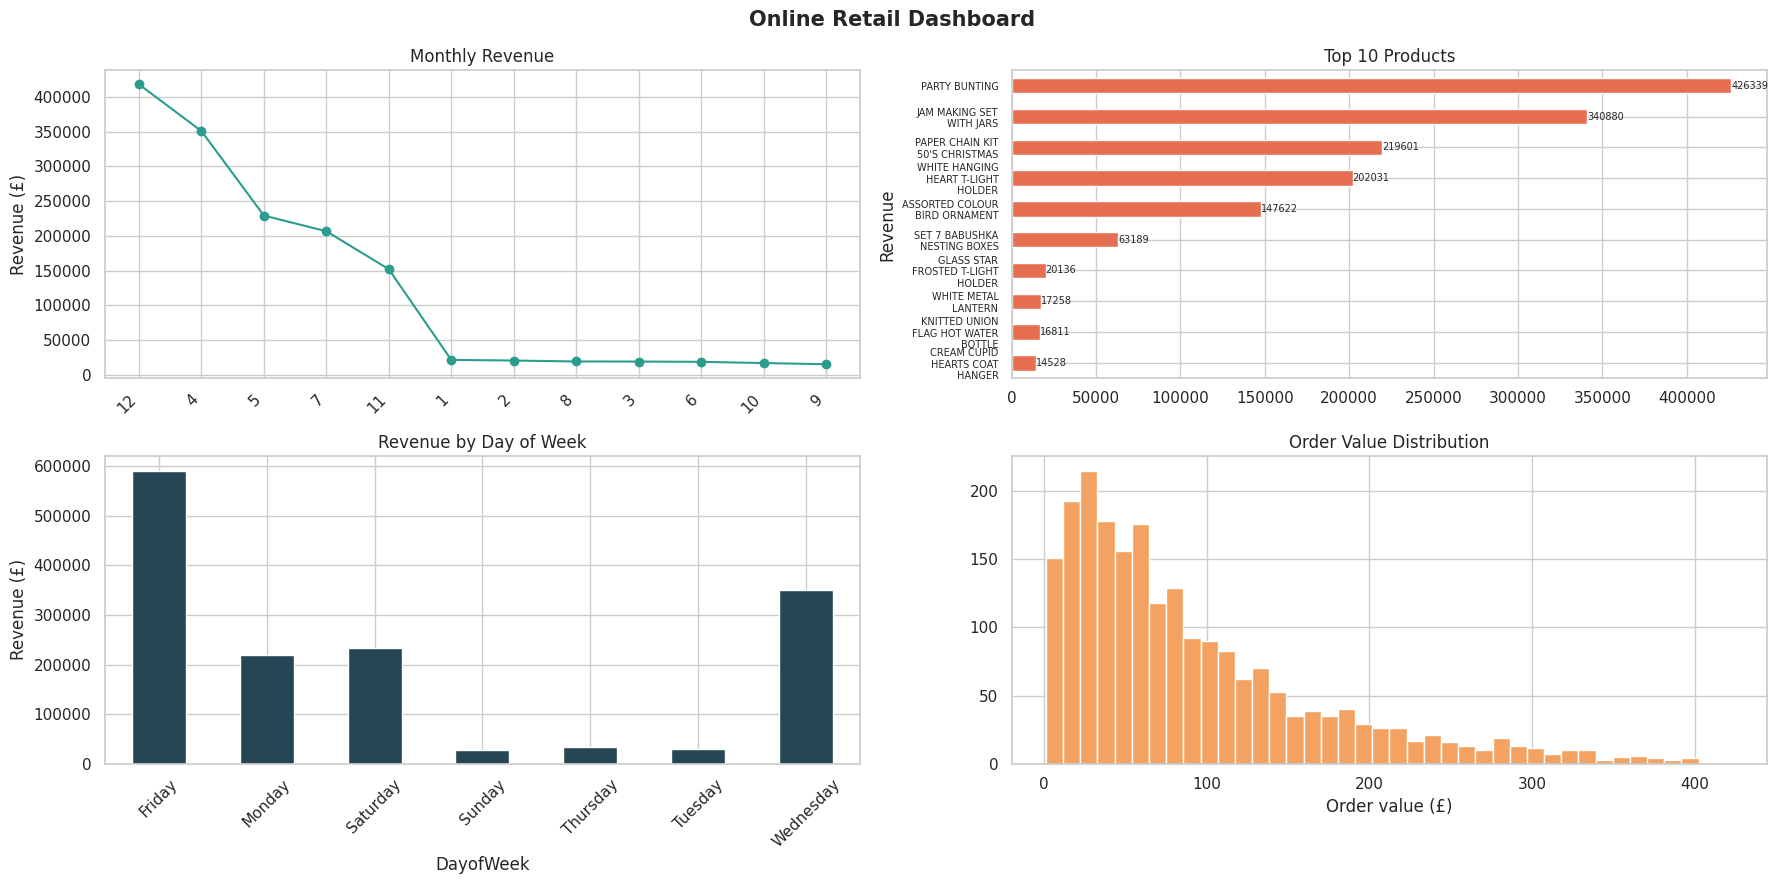

In [205]:
# your code here

order_values = sales.groupby("InvoiceNo")["revenue"].sum()

fig,ax = plt.subplots(2,2,figsize=(18,9))

ax[0,0].plot(range(len(monthly)), monthly.values, marker="o", color="#2a9d8f")
ax[0,0].set_xticks(range(len(monthly)))
ax[0,0].set_xticklabels(monthly.index, rotation=45, ha="right")
ax[0,0].set_title("Monthly Revenue")
ax[0,0].set_ylabel("Revenue (£)")


top_products_sorted = top_products.sort_values()
top_products_sorted.plot.barh(ax=ax[0,1], color="#e76f51")
ax[0,1].set_title('Top 10 Products')
ax[0,1].set_ylabel('Revenue')
ax[0,1].tick_params(axis = 'y',labelsize = 7)
for container in ax[0,1].containers:
    ax[0,1].bar_label(container, fmt='%.0f', fontsize=7)
import textwrap

top_products.index = [
    "\n".join(textwrap.wrap(x, width=15))
    for x in top_products.index
]
by_dow.plot.bar(ax=ax[1,0], color="#264653")
ax[1,0].set_title("Revenue by Day of Week"); ax[1,0].set_ylabel("Revenue (£)")
ax[1,0].tick_params(axis="x", rotation=45)

ax[1,1].hist(order_values[order_values < order_values.quantile(0.99)],
             bins=40, color="#f4a261", edgecolor="white")
ax[1,1].set_title("Order Value Distribution"); ax[1,1].set_xlabel("Order value (£)")

fig.suptitle("Online Retail Dashboard", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()






### Heatmap
Seaborn heatmap of revenue by day-of-week (rows) x hour (columns). You'll need `pivot_table`. This is the impressive one.

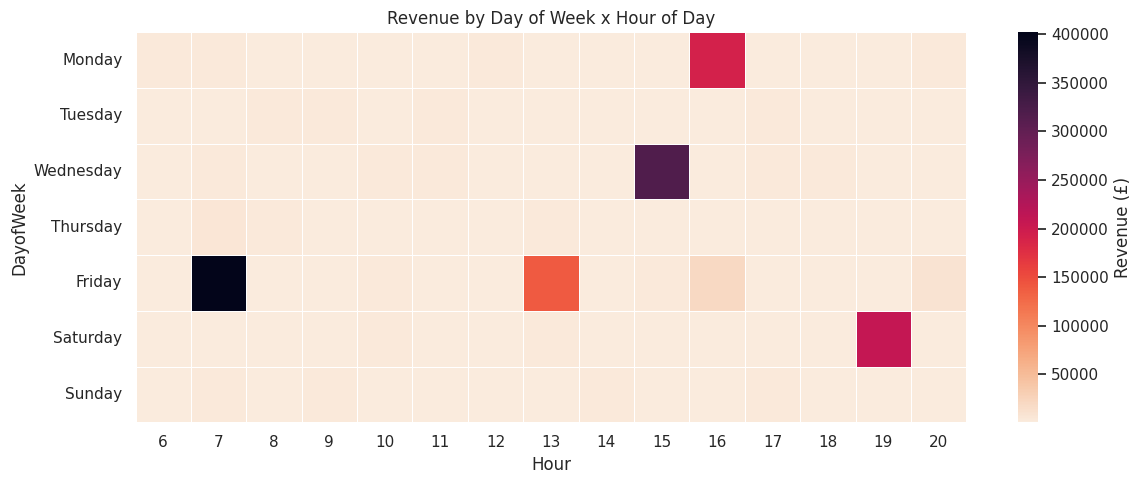

In [214]:
pivot = sales.pivot_table(index='DayofWeek', columns='Hour',values='revenue',aggfunc='sum').reindex(dow_order)
pivot

plt.figure(figsize=(12,5))
sns.heatmap(pivot, cmap="rocket_r", linewidths=.5,
            cbar_kws={"label": "Revenue (£)"})
plt.title("Revenue by Day of Week x Hour of Day")
plt.tight_layout()
plt.show()



**The 'so what' chart**
Pick the single insight you'd put in front of a manager. Make that one chart presentation-clean: clear title, annotation, no clutter. Write one sentence saying what it shows.

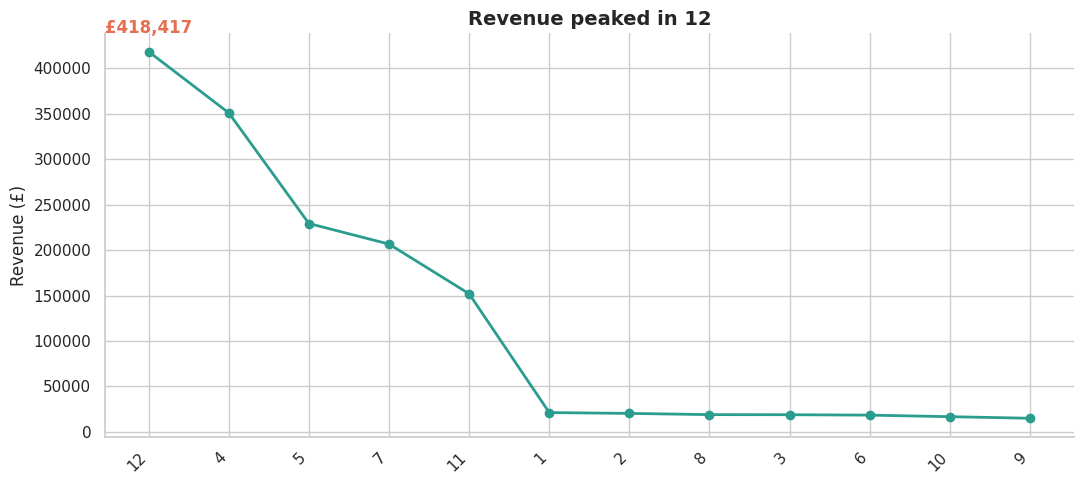

Takeaway: revenue peaked in 12 at about £418,417 — worth digging into whether that's seasonal (holiday) or a one-off.


In [207]:


peak_month = monthly.idxmax(); peak_val = monthly.max()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(len(monthly)), monthly.values, marker="o", color="#2a9d8f", linewidth=2)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=45, ha="right")
ax.set_title(f"Revenue peaked in {peak_month}", fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (£)")
ax.annotate(f"£{peak_val:,.0f}",
            xy=(monthly.values.argmax(), peak_val),
            xytext=(monthly.values.argmax(), peak_val * 1.05),
            ha="center", fontweight="bold", color="#e76f51")
for s in ["top","right"]:
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

print(f"Takeaway: revenue peaked in {peak_month} at about £{peak_val:,.0f} — "
      "worth digging into whether that's seasonal (holiday) or a one-off.")


**`SNS Charts`** Inline code

> Create different Kind Of charts with Seaborn  Bar,Line Etc

<Axes: xlabel='DayofWeek', ylabel='revenue'>

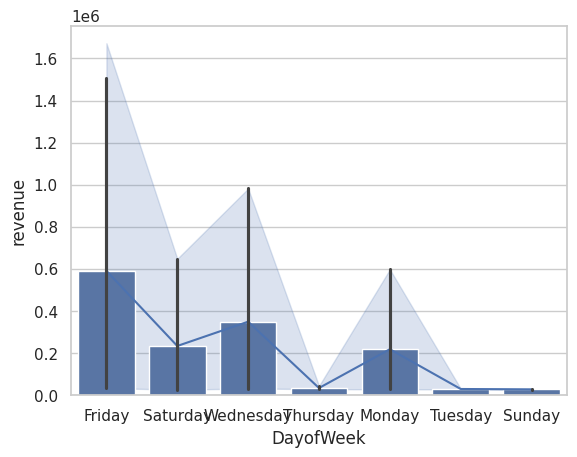

In [223]:
sns.lineplot(data=sales, x="DayofWeek", y="revenue", estimator="sum")
sns.barplot(data=sales, x="DayofWeek", y="revenue", estimator="sum")


<Axes: xlabel='Country', ylabel='count'>

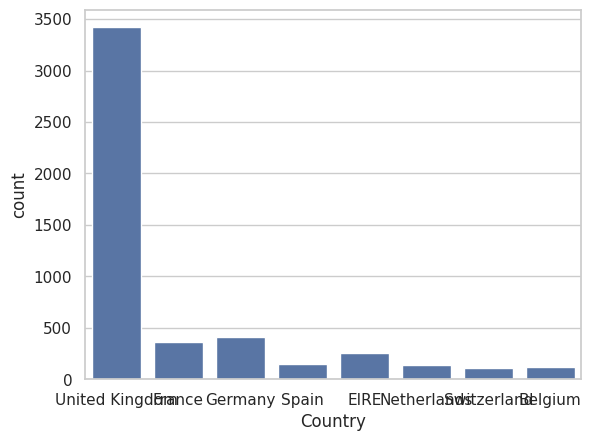

In [226]:
sns.countplot(data=sales, x="Country")